# Transcriptome-wide trans-fit parameter comparison

Compares fitted trans parameters (observed log2FC, EC50, Hill coefficient, ...) between two bayesDREAM runs, gene by gene, for every cis gene both runs have completed a `fit_trans` for.

Unlike `dose_response_comparison.ipynb` (which reloads full models to draw per-gene dose-response curves, and only scales to ~100 genes), this notebook reads each run's `trans_feature_summary_gene.csv` directly -- so it scales to Morris/Replogle's transcriptome-wide trans gene sets. See `comparative/trans_param_compare.py` for the underlying library.

**Single-Hill or not-dependent genes only, by default**: `load_trans_summary()` (and everything built on it) keeps only `fit_type in {'single_hill', 'not_dependent'}` genes -- `additive_hill` (both Hill components active) is dropped, along with polynomial-fit rows (no `fit_type` at all). A Hill-B-only gene isn't dropped though -- it's relabeled onto the same `_a`-suffixed columns a Hill-A-only gene uses, so every kept gene compares via one consistent column set regardless of which component was actually fit. Pass `single_hill_only=False` to any of these functions for the old unfiltered behavior.

Starts with the simplest comparison (observed log2FC, Morris on x vs Replogle on y), then a grid of other parameters colored by dependency category (dependent in Morris only / Replogle only / both) -- genes dependent in neither are dropped from the grid entirely. Replogle is much less powered than Morris, so points that are `is_dependent` in Morris are outlined on the starting-point plot -- watch where those land in Replogle's noisier axis.

In [1]:
# run "pip install ipython-autotime" in your conda env
%load_ext autotime

import os
import sys

# Derive the repo root from bayesDREAM's installed location (pip -e .), not
# from os.getcwd() -- the notebook's cwd at kernel start isn't guaranteed to
# be its own directory (depends on how Jupyter/the IDE was launched), so a
# '../..'-from-cwd guess silently fails to find comparative/ in that case.
# importlib.import_module (not a plain 'import bayesDREAM as ...') deliberately
# sidesteps a name collision: the bayesDREAM PACKAGE and the bayesDREAM CLASS it
# exports both share the literal name 'bayesDREAM'. If this cell's import ever
# gets merged with a 'from bayesDREAM import bayesDREAM' line elsewhere in the
# notebook, a plain import here can end up aliasing the class (no __file__)
# instead of the package -- this form can't be shadowed that way.
import importlib
_bayesdream_pkg = importlib.import_module('bayesDREAM')
REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(_bayesdream_pkg.__file__)))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import matplotlib.pyplot as plt
import pandas as pd

from comparative.datasets import DOMINGO, MORRIS, REPLOGLE, ALL_DATASETS
from comparative.trans_param_compare import (
    load_trans_summary,
    merge_pair,
    plot_obs_log2fc,
    plot_param_grid,
    plot_param_grid_by_dependency,
    compare_cis_gene,
    compare_all_shared_cis_genes,
    compare_cis_gene_grid,
    plot_pairwise_grid,
    compare_all_cis_genes_grid,
    plot_ec50_hill_with_coverage,
    load_all,
    DEFAULT_GRID_PARAMS,
)

time: 15.1 s (started: 2026-09-08 11:59:22 +02:00)


## Config

In [2]:
# Which two datasets to compare, and in which x/y order (matters for the
# scatter plots and for which dataset's is_dependent flag gets highlighted --
# see plot_obs_log2fc/plot_param_grid docstrings, dataset A drives both).
SPEC_X = MORRIS      # x-axis
SPEC_Y = REPLOGLE    # y-axis

PLOT_DIR = './trans_param_comparison_plots'
os.makedirs(PLOT_DIR, exist_ok=True)

# Extra parameters for the grid plot, beyond DEFAULT_GRID_PARAMS -- see
# comparative/trans_param_compare.py's PARAM_ALIASES for what's available.
GRID_PARAMS = DEFAULT_GRID_PARAMS
print('Datasets available:', list(ALL_DATASETS))
print(f'Comparing {SPEC_X.name} (x) vs {SPEC_Y.name} (y)')
print(f'{SPEC_X.name} cis genes with completed fit_trans: {SPEC_X.cis_genes}')
print(f'{SPEC_Y.name} cis genes with completed fit_trans: {SPEC_Y.cis_genes}')

Datasets available: ['Domingo', 'Morris', 'Replogle']
Comparing Morris (x) vs Replogle (y)
Morris cis genes with completed fit_trans: ['GFI1B', 'NFE2', 'IKZF1', 'HHEX', 'RUNX1']
Replogle cis genes with completed fit_trans: ['GFI1B', 'HHEX', 'IKZF1', 'MYB', 'NFE2', 'RUNX1', 'TET2']
time: 1.22 ms (started: 2026-09-08 11:59:38 +02:00)


## Backfill (run once per gene, or whenever a fit is re-run)

Reconstructs each dataset's fitted model (from its real production config for Domingo/Morris, from the papermill notebook's own data-loading logic for Replogle -- see `comparative/reconstruct_export.py` / `comparative/reconstruct_export_replogle.py`) and, for every cis gene:

1. backfills `trans_feature_summary_gene.csv` in place with `y_log2fc_at_xm1` (and any other `HILL_LOG2FC_TARGETS`), so it shows up in the comparisons below, and
2. exports it for `dose_response_panels.py`'s full per-gene curve panels via `save_model_for_plotting()`.

This is a full model reload per (dataset, gene) -- slow (Morris/Replogle are transcriptome-wide) -- so it's gated behind `RUN_BACKFILL` below rather than running on every notebook open. Turn it on the first time, and again any time a fit gets re-run.

**Before running this for Replogle**, confirm the assumption documented at the top of `comparative/reconstruct_export_replogle.py`: that all 7 of its `10_bayesDREAM_fit_trans_<GENE>.ipynb` notebooks are the same papermill template (same `INDIR`/`WD`/`NTC_FIT`/`CIS_FIT`/`OUTDIR`, `MIN_LOG2_MU_NTC_TRANS=-4.0`, `function_type="single_hill"`), differing only in the `gene`/`NITERS_TRANS` parameter cell -- that file hardcodes those constants once, for all 7 genes, on that assumption.

In [3]:
RUN_BACKFILL = False  # set True to (re-)run -- see the note above first

if RUN_BACKFILL:
    from comparative.reconstruct_export import reconstruct_and_export_all
    from comparative.reconstruct_export_replogle import reconstruct_and_export_all as reconstruct_and_export_all_replogle

    dm_results = reconstruct_and_export_all()                 # Domingo + Morris
    replogle_results = reconstruct_and_export_all_replogle()  # Replogle

    print('Domingo/Morris:', {k: list(v) for k, v in dm_results.items()})
    print('Replogle:', list(replogle_results))

time: 7.65 ms (started: 2026-09-08 11:59:38 +02:00)


## All shared cis genes

Loops the above over every cis gene present (with a completed fit_trans) in both datasets, saving both plots per gene to `PLOT_DIR`.

In [4]:
results = compare_all_shared_cis_genes(
    SPEC_X, SPEC_Y,
    out_dir=PLOT_DIR,
    params=GRID_PARAMS,
)
print(f"Done. Wrote plots for: {list(results)}")

Shared cis genes between Morris and Replogle: ['GFI1B', 'HHEX', 'IKZF1', 'NFE2', 'RUNX1']
[Morris] single_hill_only: kept 11033/11045 single-Hill-or-not-dependent genes (12 were Hill-B-only, relabeled onto the 'a' columns).
[Replogle] resolved 2 ambiguous gene_symbol value(s) via REPLOGLE_AMBIGUOUS_SYMBOL_TO_ID: ['TBCE', 'HSPA14']
[Replogle] single_hill_only: kept 8194/8194 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
[GFI1B] Morris: 11033 trans genes, Replogle: 8194 trans genes, shared: 7987
[Morris] single_hill_only: kept 10936/10979 single-Hill-or-not-dependent genes (20 were Hill-B-only, relabeled onto the 'a' columns).
[Replogle] resolved 2 ambiguous gene_symbol value(s) via REPLOGLE_AMBIGUOUS_SYMBOL_TO_ID: ['TBCE', 'HSPA14']
[Replogle] single_hill_only: kept 8194/8194 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
[HHEX] Morris: 10936 trans genes, Replogle: 8194 trans genes, shared: 7956
[Morris

## Grid of pairwise comparisons (all three datasets)

Adds Domingo into the mix: for a cis gene all three have a completed fit for (GFI1B, NFE2), this produces one grid per parameter -- 3 subplots (Domingo-Morris, Domingo-Replogle, Morris-Replogle), each colored/sorted by `observed_log2fc` as before.

**Comparisons against Domingo will have far fewer points than Morris-vs-Replogle** -- Domingo's own trans panel is only ~91 genes (vs. Morris/Replogle's transcriptome-wide ~20k), so this is expected, not a bug.

Each pair's join key is chosen independently: Morris-vs-Replogle merges on Ensembl `gene_id` (unambiguous); any pair involving Domingo falls back to `gene_symbol` (Domingo carries no Ensembl mapping) -- see `trans_param_compare.py`'s `merge_pair()` docstring.

[Domingo] single_hill_only: kept 76/89 single-Hill-or-not-dependent genes (3 were Hill-B-only, relabeled onto the 'a' columns).
[Morris] single_hill_only: kept 11033/11045 single-Hill-or-not-dependent genes (12 were Hill-B-only, relabeled onto the 'a' columns).
[Replogle] resolved 2 ambiguous gene_symbol value(s) via REPLOGLE_AMBIGUOUS_SYMBOL_TO_ID: ['TBCE', 'HSPA14']
[Replogle] single_hill_only: kept 8194/8194 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
Produced grids for: ['observed_log2fc', 'full_log2fc', 'y_log2fc_at_xm1', 'EC50_a_log2fc', 'n_a', 'log2_y_ntc']
[Domingo] single_hill_only: kept 89/89 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
[Morris] single_hill_only: kept 10937/10967 single-Hill-or-not-dependent genes (8 were Hill-B-only, relabeled onto the 'a' columns).
[Replogle] resolved 2 ambiguous gene_symbol value(s) via REPLOGLE_AMBIGUOUS_SYMBOL_TO_ID: ['TBCE', 'HSPA14']
[Replogle] sin

/cfs/klemming/projects/supr/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/bayesDREAM_forClaude/comparative/trans_param_compare.py:645: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, r_p = scipy_stats.pearsonr(sub[colA], sub[colB])
/cfs/klemming/projects/supr/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/bayesDREAM_forClaude/comparative/trans_param_compare.py:646: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, rho_p = scipy_stats.spearmanr(sub[colA], sub[colB])
/cfs/klemming/projects/supr/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/bayesDREAM_forClaude/comparative/trans_param_compare.py:645: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, r_p = scipy_stats.pearsonr(sub[colA], sub[colB])
/cfs/klemming/projects/supr/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/bayesDRE

Produced grids for: ['observed_log2fc', 'full_log2fc', 'y_log2fc_at_xm1', 'EC50_a_log2fc', 'n_a', 'log2_y_ntc']


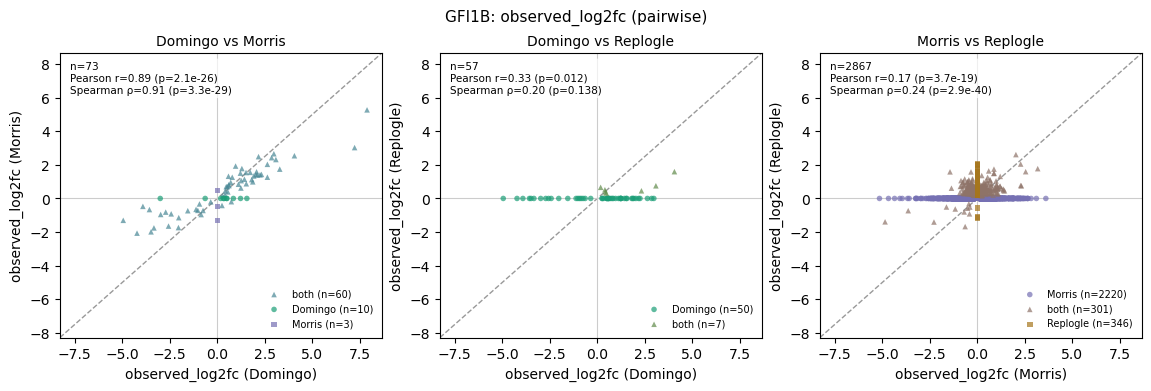

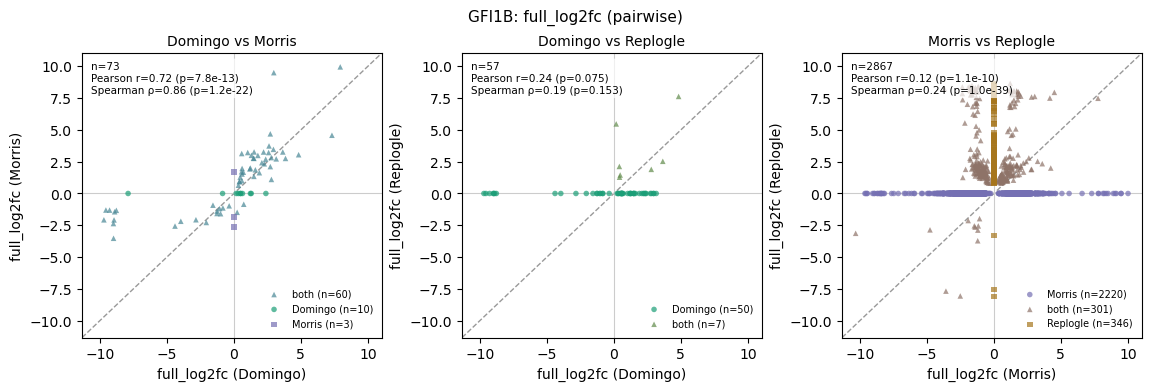

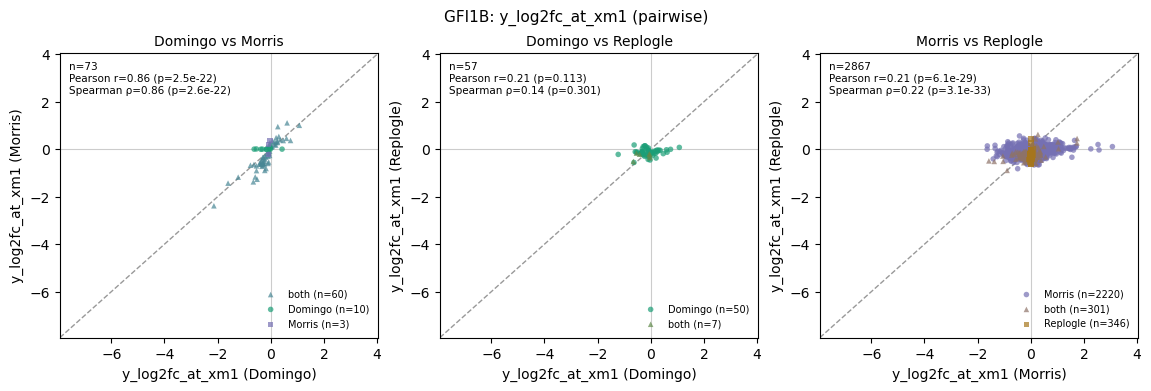

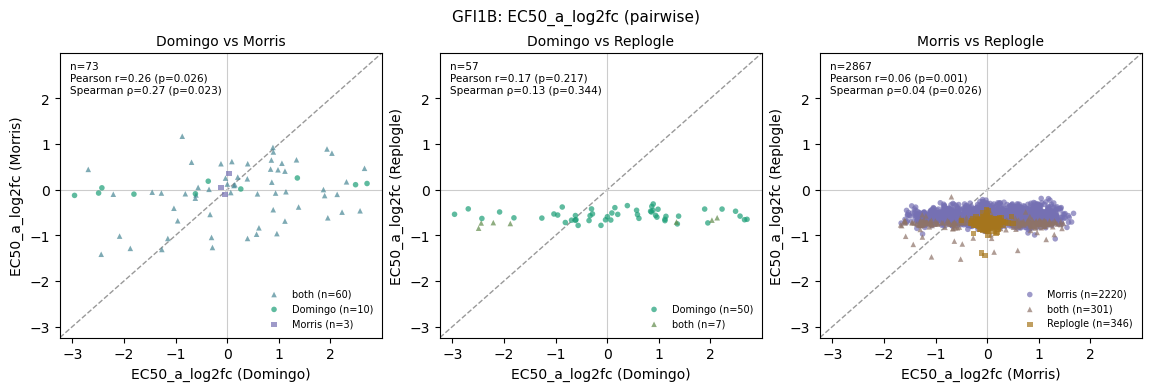

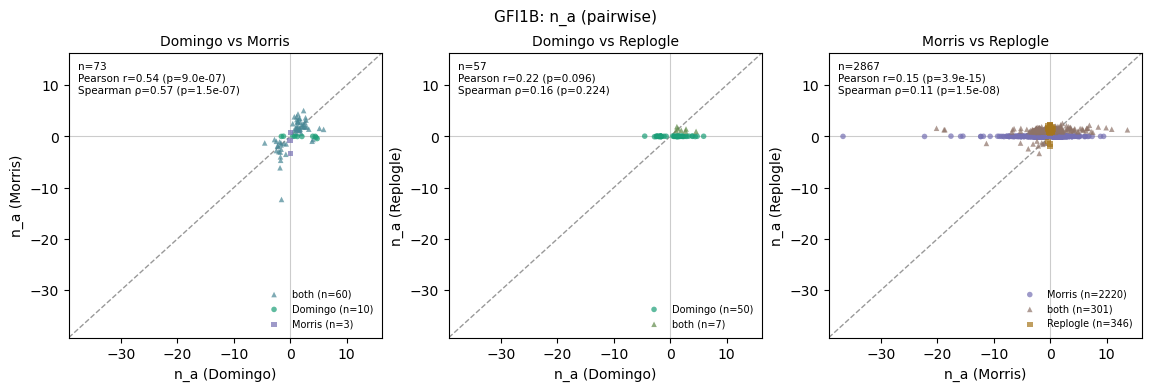

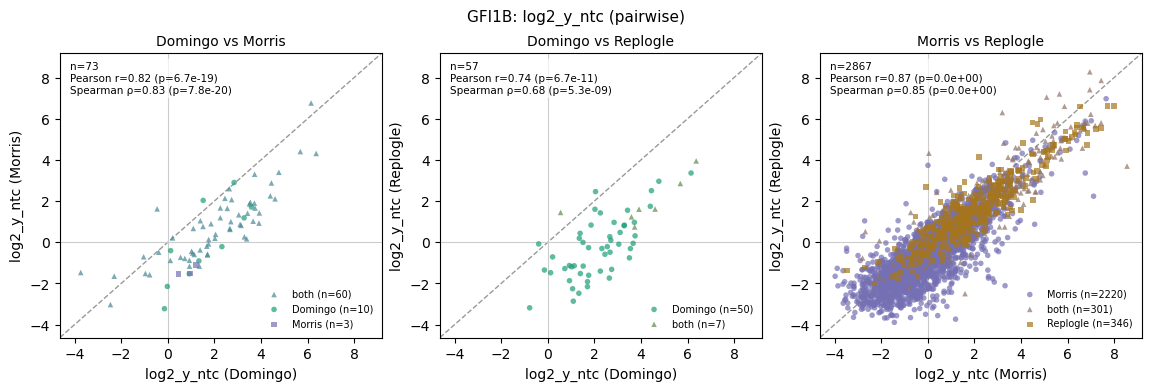

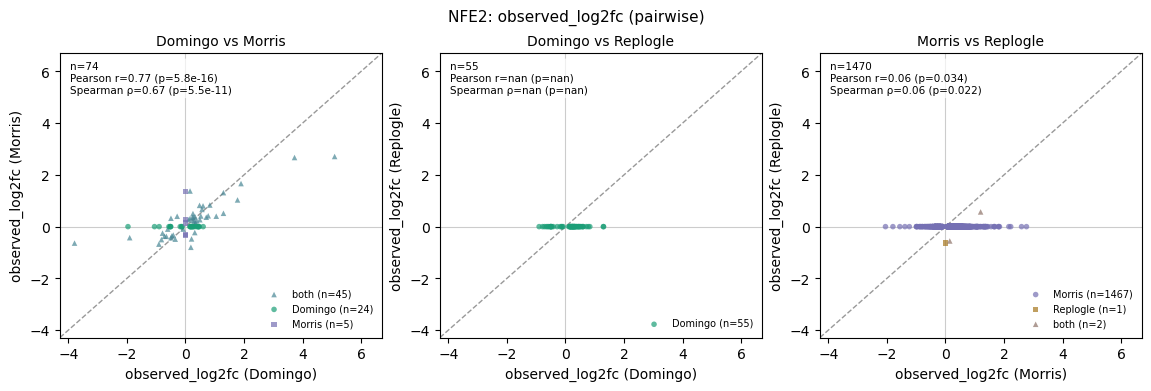

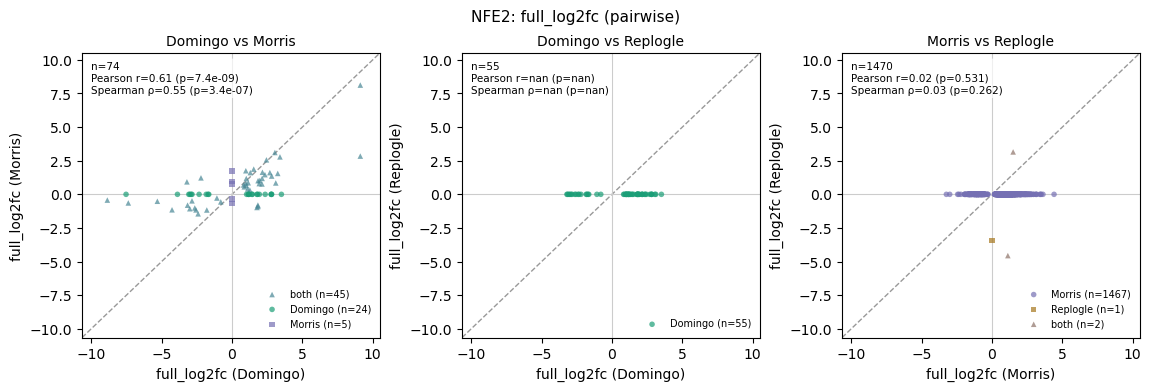

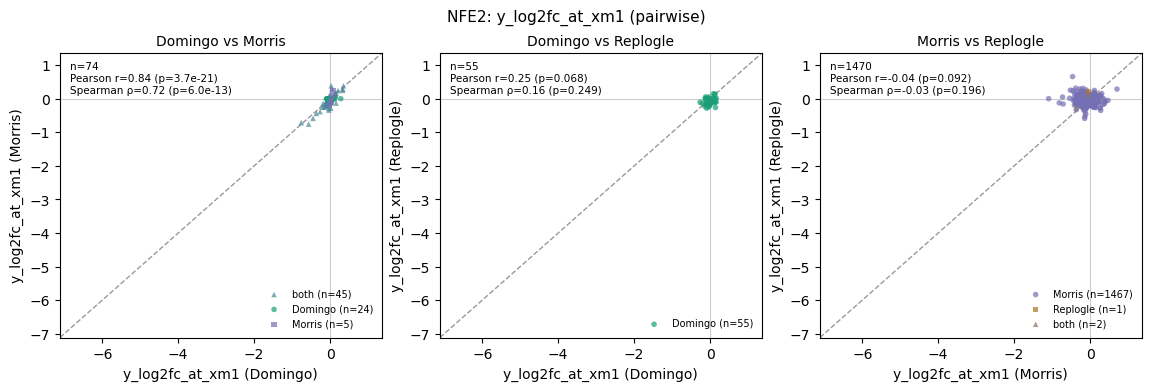

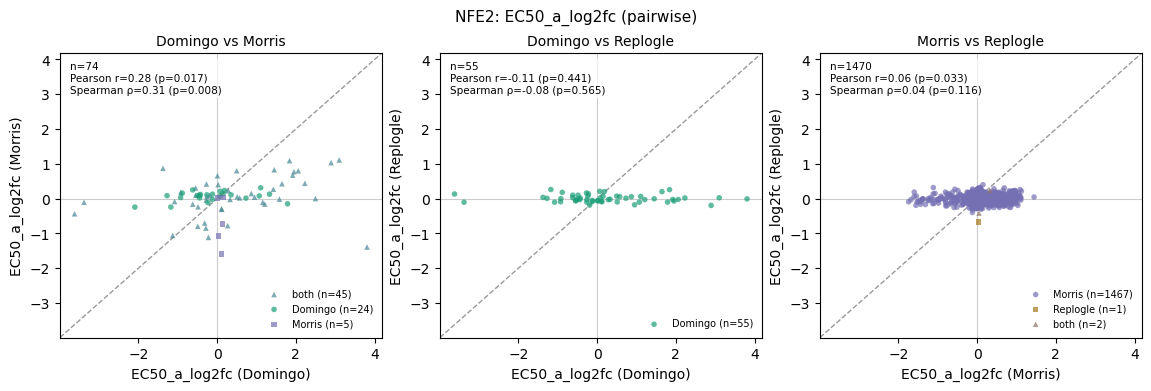

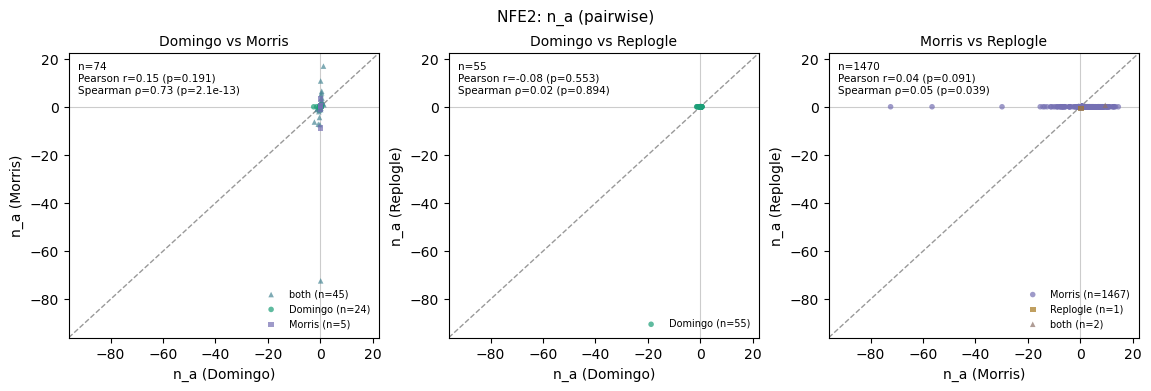

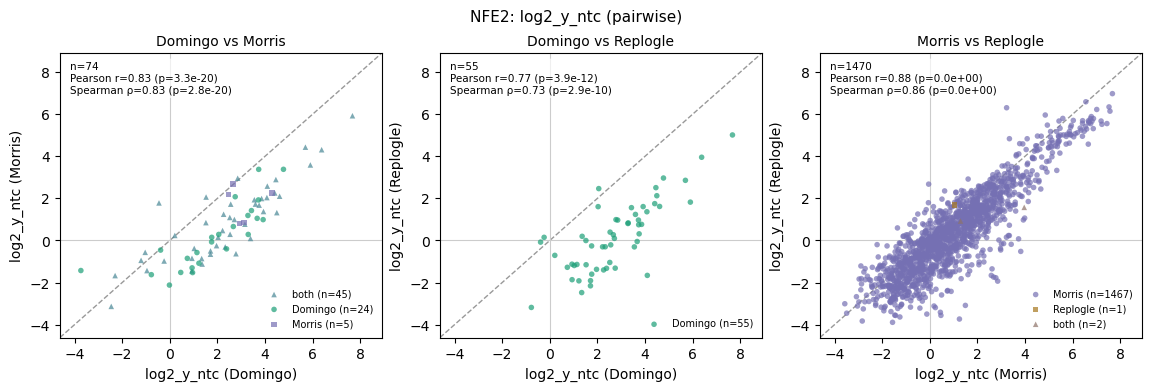

time: 16.6 s (started: 2026-09-08 11:59:53 +02:00)


In [5]:
for GRID_CIS_GENE in ['GFI1B', 'NFE2']:
    GRID_SPECS = [DOMINGO, MORRIS, REPLOGLE]
    
    dfs, figs = compare_cis_gene_grid(
        GRID_SPECS, GRID_CIS_GENE,
        out_dir=os.path.join(PLOT_DIR, 'pairwise_grids'),
    )
    print(f'Produced grids for: {list(figs)}')

[Domingo] single_hill_only: kept 87/89 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
[Replogle] resolved 2 ambiguous gene_symbol value(s) via REPLOGLE_AMBIGUOUS_SYMBOL_TO_ID: ['TBCE', 'HSPA14']
[Replogle] single_hill_only: kept 8194/8194 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
Produced grids for: ['observed_log2fc', 'full_log2fc', 'y_log2fc_at_xm1', 'EC50_a_log2fc', 'n_a', 'log2_y_ntc']
[Domingo] single_hill_only: kept 89/89 single-Hill-or-not-dependent genes (1 were Hill-B-only, relabeled onto the 'a' columns).
[Replogle] resolved 2 ambiguous gene_symbol value(s) via REPLOGLE_AMBIGUOUS_SYMBOL_TO_ID: ['TBCE', 'HSPA14']
[Replogle] single_hill_only: kept 8194/8194 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
Produced grids for: ['observed_log2fc', 'full_log2fc', 'y_log2fc_at_xm1', 'EC50_a_log2fc', 'n_a', 'log2_y_ntc']


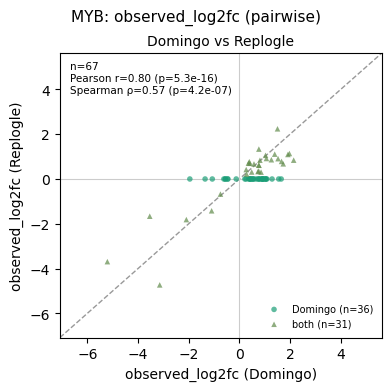

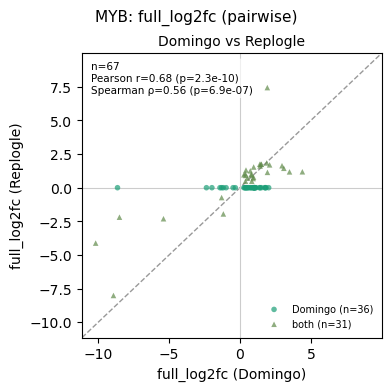

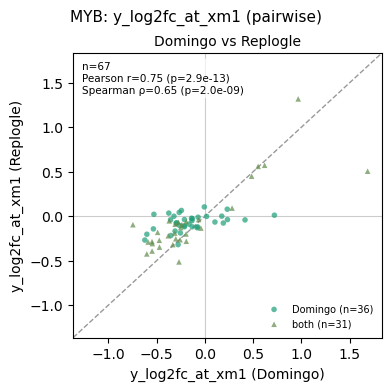

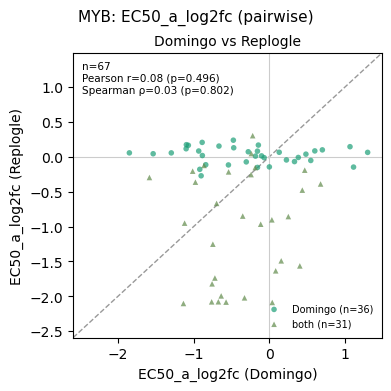

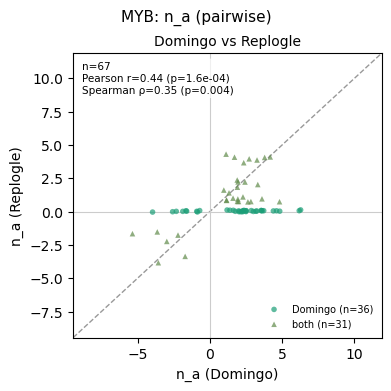

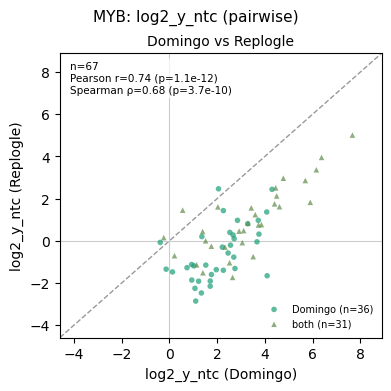

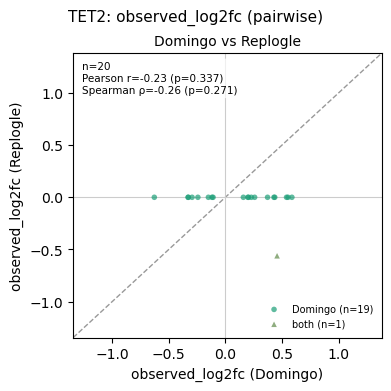

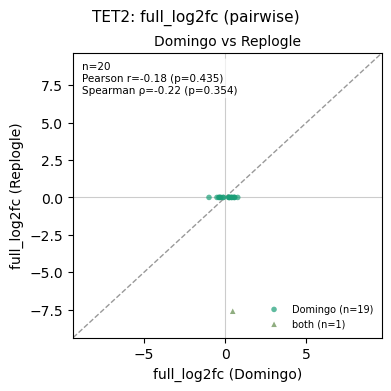

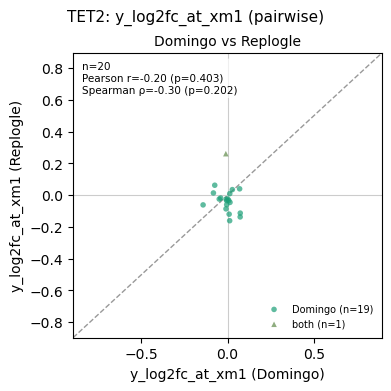

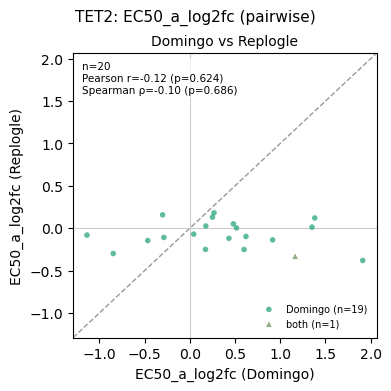

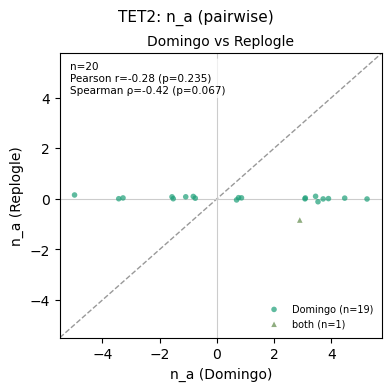

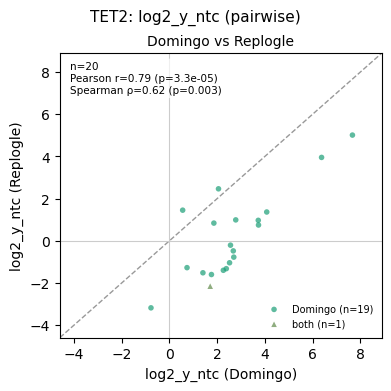

time: 6 s (started: 2026-09-08 12:00:10 +02:00)


In [6]:
for GRID_CIS_GENE in ['MYB', 'TET2']:
    GRID_SPECS = [DOMINGO, REPLOGLE]
    
    dfs, figs = compare_cis_gene_grid(
        GRID_SPECS, GRID_CIS_GENE,
        out_dir=os.path.join(PLOT_DIR, 'pairwise_grids'),
    )
    print(f'Produced grids for: {list(figs)}')

[Morris] single_hill_only: kept 10947/10947 single-Hill-or-not-dependent genes (2 were Hill-B-only, relabeled onto the 'a' columns).
[Replogle] resolved 2 ambiguous gene_symbol value(s) via REPLOGLE_AMBIGUOUS_SYMBOL_TO_ID: ['TBCE', 'HSPA14']
[Replogle] single_hill_only: kept 8194/8194 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
Produced grids for: ['observed_log2fc', 'full_log2fc', 'y_log2fc_at_xm1', 'EC50_a_log2fc', 'n_a', 'log2_y_ntc']
[Morris] single_hill_only: kept 10936/10979 single-Hill-or-not-dependent genes (20 were Hill-B-only, relabeled onto the 'a' columns).
[Replogle] resolved 2 ambiguous gene_symbol value(s) via REPLOGLE_AMBIGUOUS_SYMBOL_TO_ID: ['TBCE', 'HSPA14']
[Replogle] single_hill_only: kept 8194/8194 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).
Produced grids for: ['observed_log2fc', 'full_log2fc', 'y_log2fc_at_xm1', 'EC50_a_log2fc', 'n_a', 'log2_y_ntc']
[Morris] single_hill_only

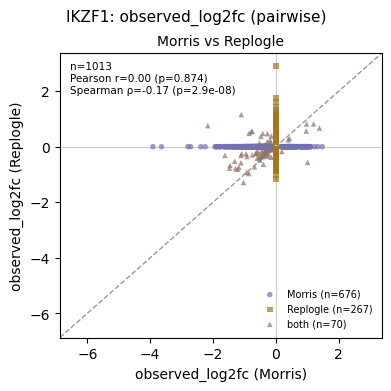

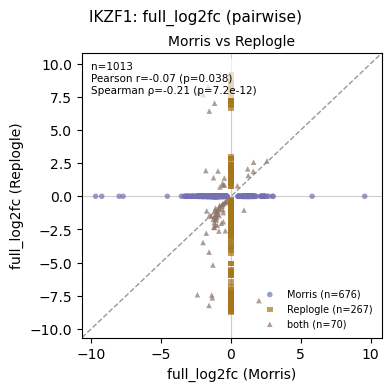

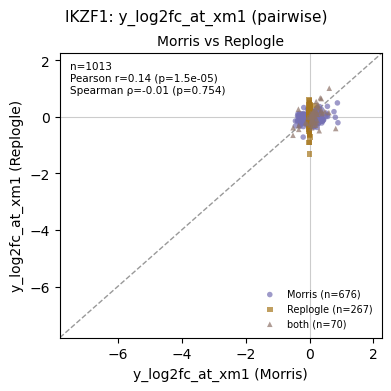

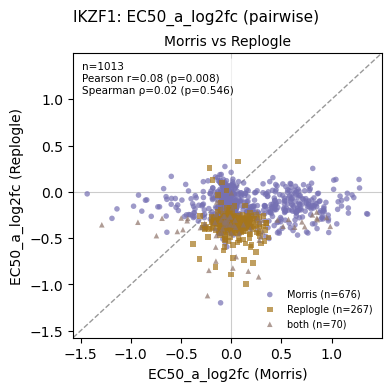

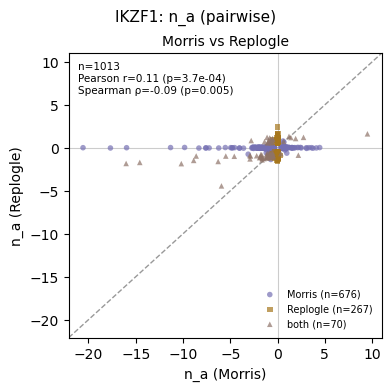

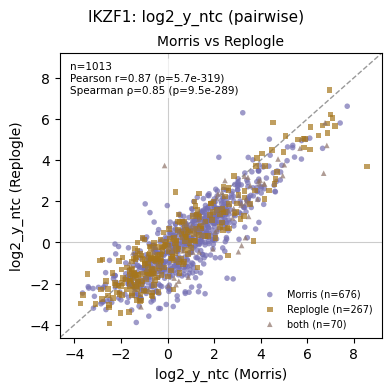

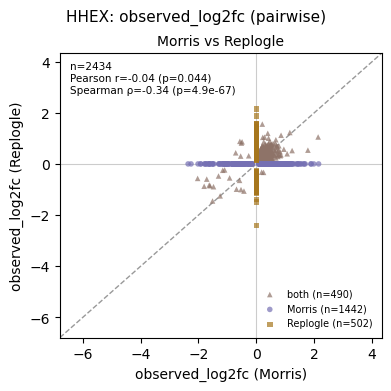

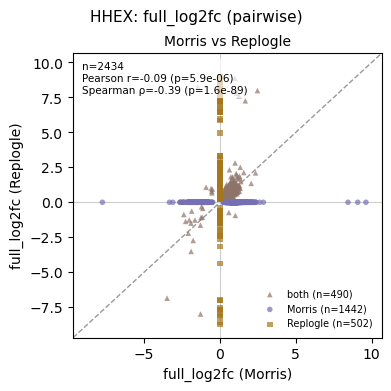

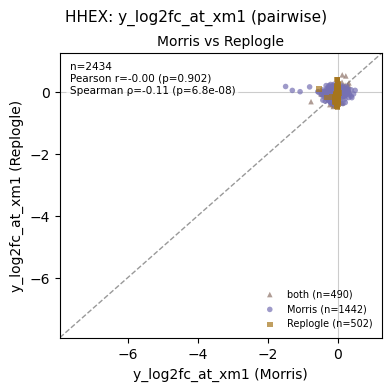

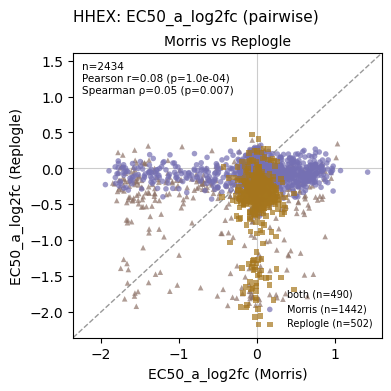

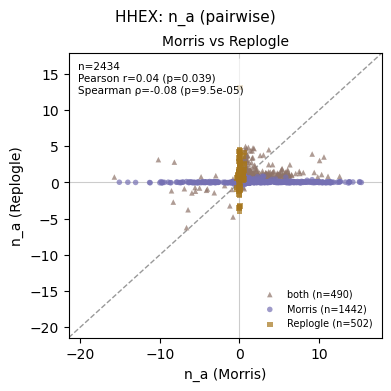

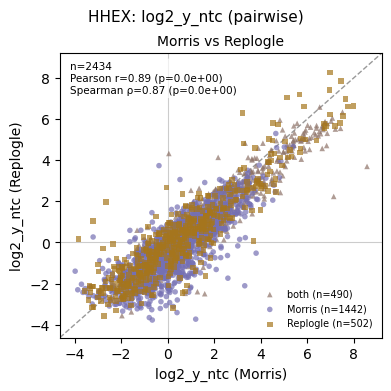

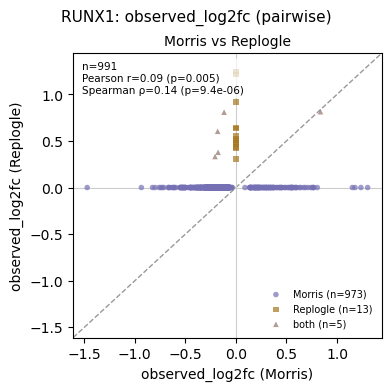

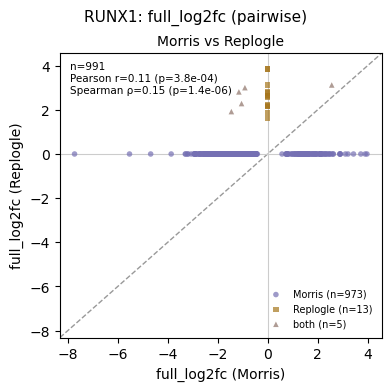

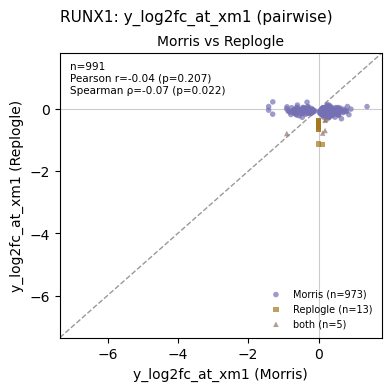

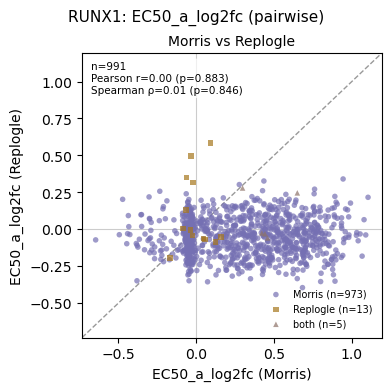

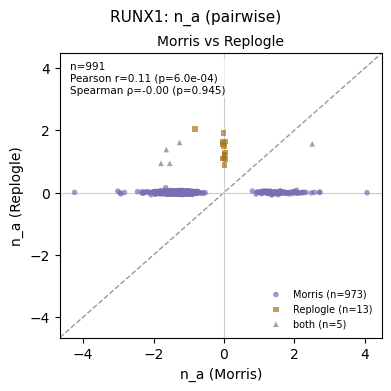

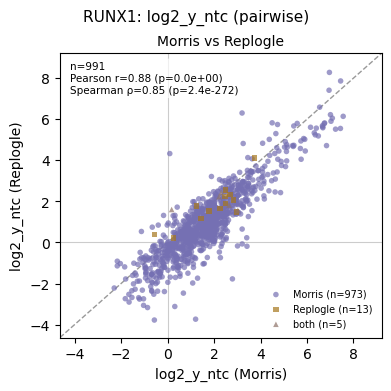

time: 12.7 s (started: 2026-09-08 12:00:16 +02:00)


In [7]:
for GRID_CIS_GENE in ['IKZF1', 'HHEX', 'RUNX1']:
    GRID_SPECS = [MORRIS, REPLOGLE]
    
    dfs, figs = compare_cis_gene_grid(
        GRID_SPECS, GRID_CIS_GENE,
        out_dir=os.path.join(PLOT_DIR, 'pairwise_grids'),
    )
    print(f'Produced grids for: {list(figs)}')

[Domingo] single_hill_only: kept 76/89 single-Hill-or-not-dependent genes (3 were Hill-B-only, relabeled onto the 'a' columns).


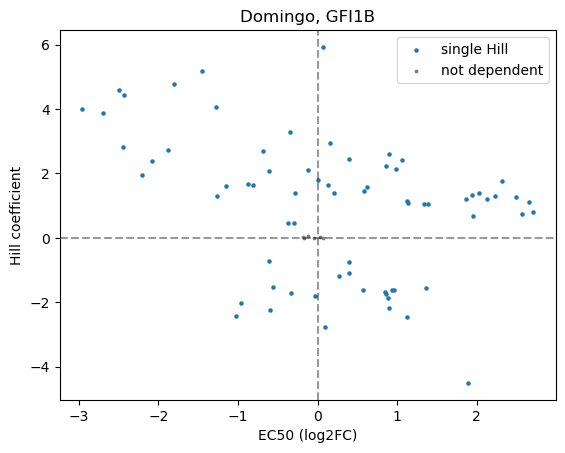

[Domingo] single_hill_only: kept 89/89 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).


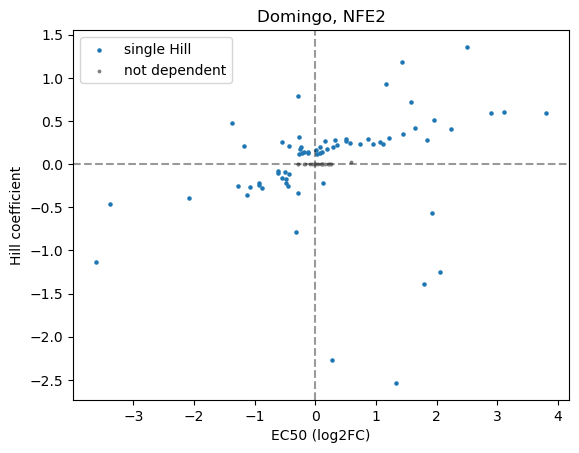

[Domingo] single_hill_only: kept 87/89 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).


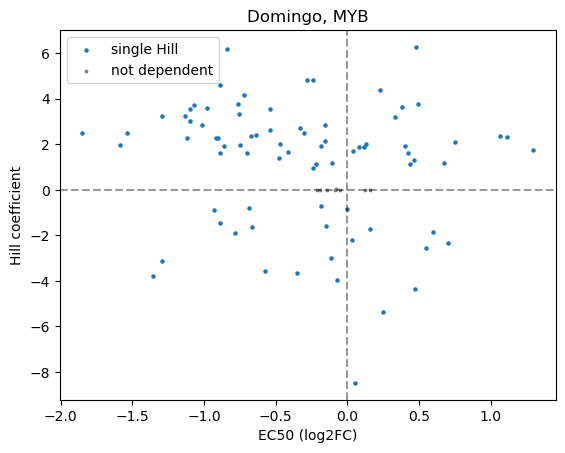

[Domingo] single_hill_only: kept 89/89 single-Hill-or-not-dependent genes (1 were Hill-B-only, relabeled onto the 'a' columns).


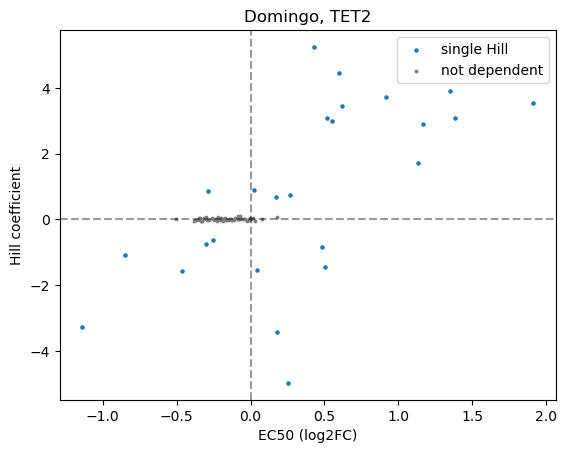

time: 1.13 s (started: 2026-09-08 12:00:28 +02:00)


In [8]:
for cis_gene in ['GFI1B', 'NFE2', 'MYB', 'TET2']:
    
    df_domingo = load_trans_summary(DOMINGO, cis_gene)

    plt.scatter(df_domingo['EC50_a_log2fc'][df_domingo['is_dependent']], df_domingo['n_a_median'][df_domingo['is_dependent']], label='single Hill', s=5)
    plt.scatter(df_domingo['EC50_a_log2fc'][~df_domingo['is_dependent']], df_domingo['n_a_median'][~df_domingo['is_dependent']], label='not dependent', s=3, c='grey')
    plt.xlabel('EC50 (log2FC)')
    plt.ylabel('Hill coefficient')
    plt.axvline(0, linestyle='dashed', c='black', alpha=0.4)
    plt.axhline(0, linestyle='dashed', c='black', alpha=0.4)
    plt.title('Domingo, ' + cis_gene)
    plt.legend()
    plt.show()

In [ ]:
# Same EC50-vs-Hill comparison as above, with an x_true coverage density
# panel underneath (NTC/CRISPRi/CRISPRa, standard grey/steelblue/tomato
# scheme) so it's visible which EC50 values fall inside vs. outside the
# actually-observed cis-gene expression range.
for cis_gene in ['GFI1B', 'NFE2', 'MYB', 'TET2']:
    fig = plot_ec50_hill_with_coverage(DOMINGO, cis_gene)
    plt.show()


[Morris] single_hill_only: kept 11033/11045 single-Hill-or-not-dependent genes (12 were Hill-B-only, relabeled onto the 'a' columns).


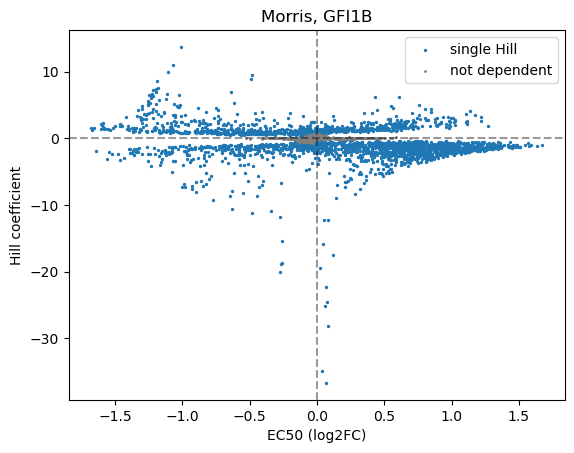

[Morris] single_hill_only: kept 10937/10967 single-Hill-or-not-dependent genes (8 were Hill-B-only, relabeled onto the 'a' columns).


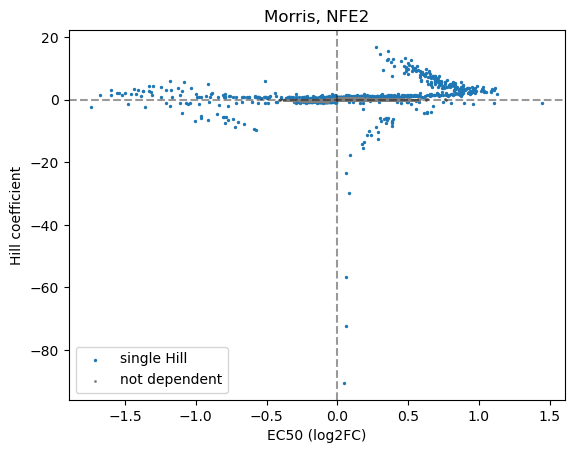

[Morris] single_hill_only: kept 10947/10947 single-Hill-or-not-dependent genes (2 were Hill-B-only, relabeled onto the 'a' columns).


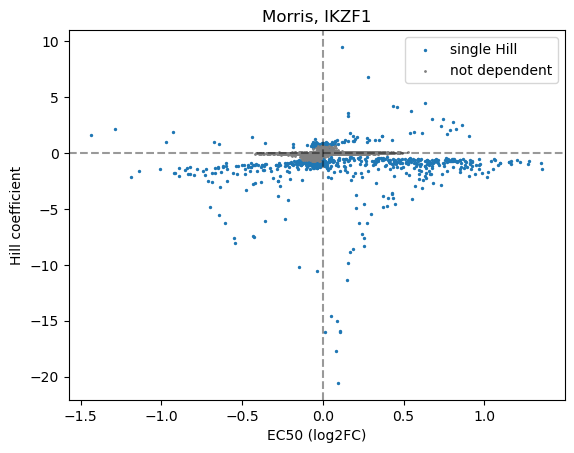

[Morris] single_hill_only: kept 10936/10979 single-Hill-or-not-dependent genes (20 were Hill-B-only, relabeled onto the 'a' columns).


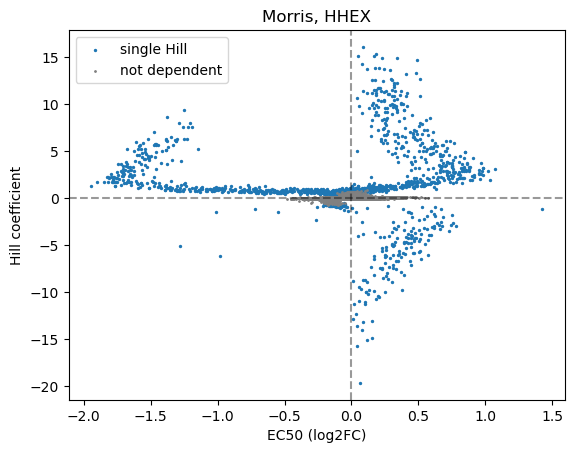

[Morris] single_hill_only: kept 10964/10964 single-Hill-or-not-dependent genes (0 were Hill-B-only, relabeled onto the 'a' columns).


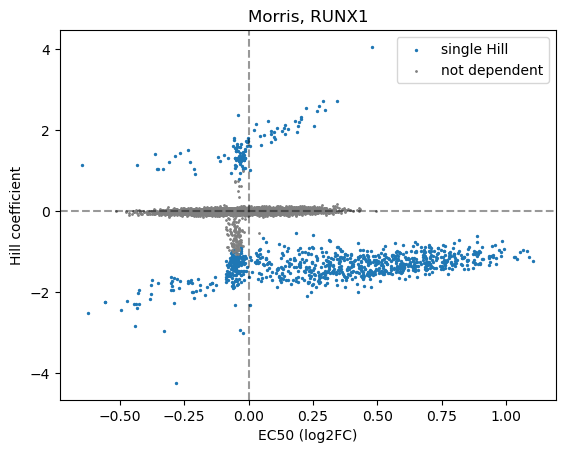

time: 5.09 s (started: 2026-09-08 12:00:29 +02:00)


In [9]:
for cis_gene in ['GFI1B', 'NFE2', 'IKZF1', 'HHEX', 'RUNX1']:
    
    df_morris = load_trans_summary(MORRIS, cis_gene)
    
    plt.scatter(df_morris['EC50_a_log2fc'][df_morris['is_dependent']], df_morris['n_a_median'][df_morris['is_dependent']], label='single Hill', s=2)
    plt.scatter(df_morris['EC50_a_log2fc'][~df_morris['is_dependent']], df_morris['n_a_median'][~df_morris['is_dependent']], label='not dependent', s=1, c='grey')
    plt.xlabel('EC50 (log2FC)')
    plt.ylabel('Hill coefficient')
    plt.axvline(0, linestyle='dashed', c='black', alpha=0.4)
    plt.axhline(0, linestyle='dashed', c='black', alpha=0.4)
    plt.title('Morris, ' + cis_gene)
    plt.legend()
    plt.show()

In [ ]:
# Same coverage-annotated version for Morris.
for cis_gene in ['GFI1B', 'NFE2', 'IKZF1', 'HHEX', 'RUNX1']:
    fig = plot_ec50_hill_with_coverage(MORRIS, cis_gene)
    plt.show()


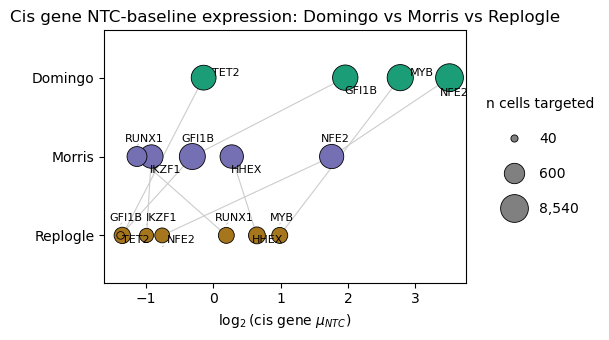

time: 2.86 s (started: 2026-09-08 12:00:34 +02:00)


In [10]:
import numpy as np
from adjustText import adjust_text

def get_mu_ntc(spec, cis_gene):
    """Cis gene's own NTC-baseline expression (mu_ntc, i.e. 'x_ntc' --
    constant across every row of that (dataset, cis_gene)'s
    trans_feature_summary, since it's a property of the CIS gene, not the
    trans genes). Returns NaN if `spec` never fit `cis_gene` at all (a
    structural gap, not an error -- same convention as compare_all_cis_genes_grid()).
    """
    if cis_gene not in spec.cis_genes:
        return np.nan
    path = spec.trans_summary_path(cis_gene)
    df = pd.read_csv(path, usecols=lambda c: c == 'x_ntc', low_memory=False)
    if 'x_ntc' not in df.columns:
        raise KeyError(f"[{spec.name}/{cis_gene}] no 'x_ntc' column in {path!r} -- re-run "
                        "reconstruct_and_export(..., force=True) to backfill it.")
    return float(df['x_ntc'].iloc[0])


def get_n_cis_cells(spec, cis_gene):
    """Number of cells classified as targeting `cis_gene` in this (dataset,
    cis_gene) run -- counted directly from meta_plot.csv's per-cell 'target'
    column (save_model_for_plotting()'s export, in spec.plotting_save_dir(),
    i.e. save_for_plotting_dir_fn -- NOT run_dir_fn/trans_summary_path's
    directory for Domingo/Morris, though the two coincide for Replogle; see
    DatasetSpec's docstring). add_cis_gene() classifies every cell as
    exactly one target identifier / 'ntc' / 'other' / 'excluded' in BOTH
    single-guide and high-MOI mode (a single label per cell, never a list --
    high-MOI's per-guide comma-separated 'targets' only lives in guide-level
    exports like cis_guide_summary.csv, which was never written for any of
    these three datasets' real production runs; see run_cis_deferred.py,
    which only calls save_cis_fit(), not save_cis_summary()). So a plain
    equality check against the per-cell column is correct in both modes,
    and doesn't need a guide-level file at all. NTC cells (target == 'ntc')
    are deliberately excluded here -- this is cells TARGETED, not the total
    fit size (targeting + NTC).

    The identifier meta['target'] was reclassified to is whatever was
    passed to add_cis_gene(), NOT necessarily the gene symbol -- for
    Replogle specifically, reconstruct_export_replogle.py's
    reconstruct_model() calls add_cis_gene(gene_id) with the Ensembl ID
    (meta['target'] there is built from a 'target' column already encoded
    as gene_id/'ntc', see _load_gene_model_inputs()), so comparing against
    the bare symbol would silently match zero cells. spec.cis_gene_id_fn is
    the SAME translation datasets.py documents for this exact mismatch
    (symbol -> saved-identifier), so reuse it here rather than hardcoding
    Replogle as a special case.

    Returns NaN if `spec` never fit `cis_gene` at all -- same convention as
    get_mu_ntc().
    """
    if cis_gene not in spec.cis_genes:
        return np.nan
    save_dir = spec.plotting_save_dir(cis_gene)
    path = os.path.join(save_dir, 'meta_plot.csv')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"[{spec.name}/{cis_gene}] no meta_plot.csv at {path!r} -- has "
            "save_model_for_plotting() been run for this gene yet?"
        )
    df = pd.read_csv(path, usecols=lambda c: c == 'target')
    if 'target' not in df.columns:
        raise KeyError(f"[{spec.name}/{cis_gene}] no 'target' column in {path!r}.")
    target_id = spec.cis_gene_id_fn(cis_gene) if spec.cis_gene_id_fn else cis_gene
    return float((df['target'] == target_id).sum())


def make_size_scaler(n_cells_all, s_min=30, s_max=400):
    """Fit a log2(n_cells) -> scatter `s` (points^2, i.e. marker AREA) scale
    on `n_cells_all`'s own range, and return a function applying that FIXED
    scale to any n_cells value(s) -- so the plotted points and the legend
    markers (each scaled on a different-sized input) land on the same scale
    instead of each being independently stretched to fill [s_min, s_max].
    log2 (rather than sqrt) compresses the huge range here (tens to
    thousands of cells targeted) so small-n points stay visible instead of
    shrinking to near-invisible dots next to NFE2/Domingo's ~8,540.
    """
    log2_all = np.log2(np.asarray(n_cells_all, dtype=float))
    lo, hi = np.nanmin(log2_all), np.nanmax(log2_all)
    def scale(n_cells):
        log2_n = np.log2(np.asarray(n_cells, dtype=float))
        if not np.isfinite(hi - lo) or hi <= lo:
            return np.full_like(log2_n, (s_min + s_max) / 2)
        return s_min + (log2_n - lo) / (hi - lo) * (s_max - s_min)
    return scale


CIS_GENES_MU_NTC = ['GFI1B', 'NFE2', 'MYB', 'TET2', 'IKZF1', 'HHEX', 'RUNX1']
SPECS_MU_NTC = [DOMINGO, MORRIS, REPLOGLE]

mu_ntc_df = pd.DataFrame([
    {'cis_gene': gene, 'dataset': spec.name,
     'mu_ntc': get_mu_ntc(spec, gene), 'n_cells': get_n_cis_cells(spec, gene)}
    for gene in CIS_GENES_MU_NTC for spec in SPECS_MU_NTC
]).dropna(subset=['mu_ntc'])
mu_ntc_df['log2_mu_ntc'] = np.log2(mu_ntc_df['mu_ntc'])

size_scale = make_size_scaler(mu_ntc_df['n_cells'])
mu_ntc_df['marker_size'] = size_scale(mu_ntc_df['n_cells'])
mu_ntc_df

fig, ax = plt.subplots(figsize=(6, 3.5))

# Top-to-bottom row order matches SPECS_MU_NTC's order (Domingo, Morris, Replogle).
y_pos = {spec.name: i for i, spec in enumerate(reversed(SPECS_MU_NTC))}
spec_by_name = {spec.name: spec for spec in SPECS_MU_NTC}

# One COMBINED scatter call (not one call per point) -- adjust_text's
# objects= repels labels using each point's REAL marker footprint (size
# included, via the PathCollection's per-offset transforms), not just its
# center coordinate, but that only works when it's handed a single
# PathCollection with one offset+size per point (get_bboxes_pathcollection's
# assumption). Sorted biggest-to-smallest first so draw order still puts the
# smallest (hardest to see if buried) circles on top, same as the old
# per-point-call loop -- a single scatter() draws its offsets in array
# order, so this sort has the same effect here as it did across separate
# calls.
plot_df = mu_ntc_df.sort_values('marker_size', ascending=False)
point_collection = ax.scatter(
    plot_df['log2_mu_ntc'], plot_df['dataset'].map(y_pos),
    color=[spec_by_name[d].color for d in plot_df['dataset']],
    s=plot_df['marker_size'], edgecolor='black', linewidth=0.6, zorder=3,
)

# Labels, staggered above/below their row (alternating by x-order within
# the row) BEFORE handing off to adjust_text below. Starting every label on
# the same side (all above) gave adjust_text a symmetric configuration it
# mostly resolved by sliding labels sideways -- moving one down into the
# row's own empty space costs it exactly as much as moving another one
# further sideways, so it rarely chose to. Alternating the START side means
# roughly half of each row's labels are ALREADY below, which is enough of a
# nudge for the physics to actually use that space, on top of whatever
# further repulsion still needs to happen (labels can still move to
# whichever side clears their particular collision).
labels = []
for dataset in y_pos:
    sub = mu_ntc_df[mu_ntc_df['dataset'] == dataset].sort_values('log2_mu_ntc')
    for i, (_, row) in enumerate(sub.iterrows()):
        above = (i % 2 == 0)
        labels.append(ax.text(
            row['log2_mu_ntc'], y_pos[dataset] + (0.14 if above else -0.14),
            row['cis_gene'], ha='center', va=('bottom' if above else 'top'), fontsize=8,
        ))

# Connect the same cis gene across whichever datasets fit it (2 or 3 points),
# sorted by row so the line doesn't zigzag.
pivot = mu_ntc_df.pivot(index='cis_gene', columns='dataset', values='log2_mu_ntc')
for gene, r in pivot.iterrows():
    present = r.dropna()
    if len(present) < 2:
        continue
    ys = sorted(y_pos[name] for name in present.index)
    xs = [present[[name for name in present.index if y_pos[name] == y][0]] for y in ys]
    ax.plot(xs, ys, color='#ccc', lw=0.8, zorder=1)

# Repel overlapping labels -- avoid_self (default) keeps a label away from
# OTHER labels; objects=point_collection additionally keeps labels away from
# every scatter point's ACTUAL rendered circle (position + size), not just
# its center -- otherwise a big circle (e.g. NFE2/Domingo at ~8,540 cells)
# has plenty of room around its center coordinate that's still visually
# inside the marker. force_pull (default) still pulls each label back
# toward its own anchor point, so it drifts only as far as needed to clear
# a collision; a thin grey leader line is drawn wherever a label actually
# had to move, so it stays traceable to its point.
adjust_text(
    labels, ax=ax, objects=point_collection,
    force_text=(0.3, 0.5), force_static=(0.3, 0.5), expand=(1.2, 1.6),
    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5, alpha=0.6),
)

ax.set_yticks(sorted(y_pos.values()))
ax.set_yticklabels([spec.name for spec in reversed(SPECS_MU_NTC)])
ax.set_ylim(min(y_pos.values()) - 0.6, max(y_pos.values()) + 0.6)
ax.set_xlabel(r'$\log_2$(cis gene $\mu_{NTC}$)')
ax.set_title('Cis gene NTC-baseline expression: Domingo vs Morris vs Replogle')

# Marker-size legend: a few representative n_cells values spanning this
# plot's own range, LOG-spaced to match the log2 size scale (linear spacing
# would crowd the legend's high end together, same as it would have on the
# plot itself before the log2 switch) -- scaled with the SAME size_scale fit
# above, then converted from scatter `s` (area) to legend markersize
# (diameter, i.e. sqrt(s)) so the legend circles match the plotted ones
# exactly.
legend_n = sorted(set(np.geomspace(mu_ntc_df['n_cells'].min(), mu_ntc_df['n_cells'].max(), 3).round(-1).astype(int)))
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor='grey',
               markeredgecolor='black', markeredgewidth=0.6, markersize=np.sqrt(size_scale(n)),
               label=f'{n:,}')
    for n in legend_n
]
ax.legend(handles=legend_handles, title='n cells targeted', loc='center left',
          bbox_to_anchor=(1.02, 0.5), frameon=False, labelspacing=1.5)

fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'mu_ntc_domingo_vs_morris_vs_replogle.png'), dpi=150, bbox_inches='tight')
plt.show()